In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import mlflow
import mlflow.pytorch
import pandas as pd
import glob, os, sys
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append('..')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cpu


In [3]:
class HAMDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.label_map = {
            'nv':0,'mel':1,'bkl':2,
            'bcc':3,'akiec':4,'vasc':5,'df':6
        }
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.label_map[row['dx']]

# Reload data
df = pd.read_csv("../data/HAM10000_metadata.csv")
part1 = glob.glob("../data/HAM10000_images_part_1/*.jpg")
part2 = glob.glob("../data/HAM10000_images_part_2/*.jpg")
all_images = part1 + part2
image_paths = {os.path.splitext(os.path.basename(p))[0]: p for p in all_images}
df['image_path'] = df['image_id'].map(image_paths)
df = df.dropna(subset=['image_path'])

# Split
train_df = df.iloc[:int(0.70*len(df))]
val_df   = df.iloc[int(0.70*len(df)):int(0.85*len(df))]

train_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])
val_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

train_loader = DataLoader(HAMDataset(train_df, train_transform), batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(HAMDataset(val_df,   val_transform),   batch_size=32, shuffle=False, num_workers=0)

print(f"Train: {len(train_df)} | Val: {len(val_df)}")
# Same HAMDataset class here...
# (copy from day3 notebook cell 2)

df = pd.read_csv("../data/HAM10000_metadata.csv")
part1 = glob.glob("../data/HAM10000_images_part_1/*.jpg")
part2 = glob.glob("../data/HAM10000_images_part_2/*.jpg")
all_images = part1 + part2
image_paths = {os.path.splitext(os.path.basename(p))[0]: p for p in all_images}
df['image_path'] = df['image_id'].map(image_paths)
df = df.dropna(subset=['image_path'])

# Three way split this time
total      = len(df)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)

train_df = df.iloc[:train_size]
val_df   = df.iloc[train_size:train_size + val_size]
test_df  = df.iloc[train_size + val_size:]

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

train_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])
val_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

train_loader = DataLoader(HAMDataset(train_df, train_transform), batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(HAMDataset(val_df,   val_transform),   batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(HAMDataset(test_df,  val_transform),   batch_size=32, shuffle=False, num_workers=0)

Train: 7010 | Val: 1502
Train: 7010 | Val: 1502 | Test: 1503


In [4]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.001):
        self.patience   = patience    # how many epochs to wait
        self.min_delta  = min_delta   # minimum improvement to count
        self.counter    = 0
        self.best_loss  = float('inf')
        self.should_stop = False

    def check(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            # Improved — reset counter
            self.best_loss = val_loss
            self.counter   = 0
        else:
            # Did not improve
            self.counter += 1
            print(f"  EarlyStopping: no improvement for {self.counter}/{self.patience} epochs")
            if self.counter >= self.patience:
                self.should_stop = True
                print("  ⛔ Early stopping triggered!")

early_stopper = EarlyStopping(patience=3)
print("EarlyStopping class ready ✅")
print("Explanation: if val_loss doesn't improve for 3 epochs in a row, training stops automatically")

EarlyStopping class ready ✅
Explanation: if val_loss doesn't improve for 3 epochs in a row, training stops automatically


In [6]:
# Copy CNN class here from Day 3
class CNN(nn.Module):
    def __init__(self, num_classes=7):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool  = nn.MaxPool2d(2, 2)
        self.relu  = nn.ReLU()
        self.drop  = nn.Dropout(0.3)
        self.fc1   = nn.Linear(128 * 8 * 8, 256)
        self.fc2   = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.drop(self.relu(self.fc1(x)))
        return self.fc2(x)

print("CNN defined ✅")
def get_class_weights(dataframe):
    label_map = {'nv':0,'mel':1,'bkl':2,'bcc':3,'akiec':4,'vasc':5,'df':6}
    counts  = Counter(dataframe['dx'].map(label_map))
    total   = len(dataframe)
    weights = torch.zeros(7)
    for cls, count in counts.items():
        weights[cls] = total / (7 * count)
    return weights.to(device)

mlflow.set_experiment("ham10000-cnn-final")

model     = CNN(num_classes=7).to(device)
weights   = get_class_weights(train_df)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)
stopper   = EarlyStopping(patience=3)

best_val_acc  = 0
train_losses  = []
val_losses    = []

with mlflow.start_run(run_name="final-training-early-stopping"):
    mlflow.log_params({
        "lr": 0.001, "batch_size": 32,
        "patience": 3, "max_epochs": 20,
        "early_stopping": True
    })
    
    for epoch in range(20):  # max 20 epochs
        # --- Train ---
        model.train()
        tr_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            out  = model(images)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            tr_loss += loss.item()
            correct += out.argmax(1).eq(labels).sum().item()
            total   += labels.size(0)
        
        tr_loss /= len(train_loader)
        tr_acc   = 100. * correct / total
        
        # --- Validate ---
        model.eval()
        vl_loss, vcorrect, vtotal = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                out      = model(images)
                vl_loss += criterion(out, labels).item()
                vcorrect += out.argmax(1).eq(labels).sum().item()
                vtotal   += labels.size(0)
        
        vl_loss /= len(val_loader)
        vl_acc   = 100. * vcorrect / vtotal
        
        train_losses.append(tr_loss)
        val_losses.append(vl_loss)
        
        # Log to MLflow
        mlflow.log_metrics({
            "train_loss": tr_loss, "train_acc": tr_acc,
            "val_loss":   vl_loss, "val_acc":   vl_acc
        }, step=epoch)
        
        print(f"Epoch {epoch+1:02d}/20 | "
              f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.1f}% | "
              f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.1f}%")
        
        # Save best model
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), "../model/best_cnn.pth")
            print(f"  💾 Best model saved! Val acc: {best_val_acc:.1f}%")
        
        # Check early stopping
        stopper.check(vl_loss)
        if stopper.should_stop:
            print(f"\nStopped at epoch {epoch+1}")
            break
    
    mlflow.log_metric("best_val_acc", best_val_acc)
    mlflow.pytorch.log_model(model, "final_model")
    print(f"\n✅ Training complete. Best val accuracy: {best_val_acc:.1f}%")

CNN defined ✅
Epoch 01/20 | Train Loss: 1.6072 Acc: 56.2% | Val Loss: 2.9689 Acc: 5.7%
  💾 Best model saved! Val acc: 5.7%
Epoch 02/20 | Train Loss: 1.2690 Acc: 63.8% | Val Loss: 3.6378 Acc: 3.3%
  EarlyStopping: no improvement for 1/3 epochs
Epoch 03/20 | Train Loss: 1.1594 Acc: 66.3% | Val Loss: 3.1868 Acc: 4.2%
  EarlyStopping: no improvement for 2/3 epochs
Epoch 04/20 | Train Loss: 1.1686 Acc: 66.4% | Val Loss: 2.6545 Acc: 10.2%
  💾 Best model saved! Val acc: 10.2%
Epoch 05/20 | Train Loss: 1.1041 Acc: 68.4% | Val Loss: 3.0973 Acc: 10.1%
  EarlyStopping: no improvement for 1/3 epochs
Epoch 06/20 | Train Loss: 1.0917 Acc: 68.9% | Val Loss: 3.9292 Acc: 2.3%
  EarlyStopping: no improvement for 2/3 epochs


2026/07/08 22:50:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Epoch 07/20 | Train Loss: 1.0319 Acc: 71.2% | Val Loss: 3.4797 Acc: 1.8%
  EarlyStopping: no improvement for 3/3 epochs
  ⛔ Early stopping triggered!

Stopped at epoch 7


MlflowException: If `serialization_format` is set to 'pt2', then input_example is required. It must be a numpy array or torch tensor, or a tuple/list of numpy arrays or torch tensors. This is because 'pt2' is a traced-graph format: PyTorch traces the model graph by virtually executing model.forward with the provided example input.

In [7]:
with mlflow.start_run(run_name="log-final-model"):
    mlflow.pytorch.log_model(
        model,
        "final_model",
        serialization_format="pickle"
    )
    mlflow.log_metric("best_val_acc", best_val_acc)
    print("✅ Model logged to MLflow successfully")

2026/07/08 22:57:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/08 22:57:31 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/07/08 22:57:31 WARNING mlflow.utils.requirements_utils: Found torch version (2.12.1+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.12.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/08 22:57:51 WARNING mlflow.utils.requirements_utils: Found torch version (2.12.1+cpu) contains a local version label (+cpu

✅ Model logged to MLflow successfully


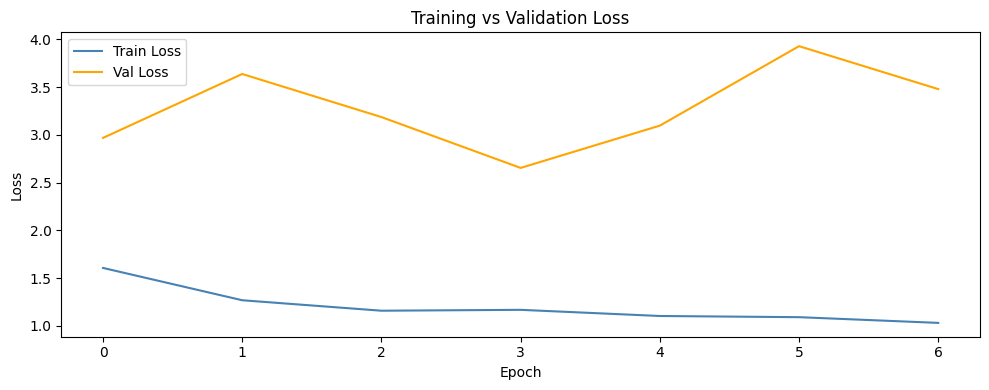

Loss curve saved to model/loss_curve.png ✅


In [8]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', color='steelblue')
plt.plot(val_losses,   label='Val Loss',   color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.tight_layout()
plt.savefig("../model/loss_curve.png")
plt.show()
print("Loss curve saved to model/loss_curve.png ✅")

In [9]:
classes = ['nv','mel','bkl','bcc','akiec','vasc','df']

# Load best model
best_model = CNN(num_classes=7).to(device)
best_model.load_state_dict(torch.load("../model/best_cnn.pth", map_location=device))
best_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        out    = best_model(images)
        preds  = out.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))

Classification Report:
              precision    recall  f1-score   support

          nv       0.61      0.05      0.10      1170
         mel       0.00      0.67      0.01         3
         bkl       0.01      1.00      0.01         3
         bcc       0.00      0.00      0.00         0
       akiec       0.00      0.00      0.00       327
        vasc       0.00      0.00      0.00         0
          df       0.00      0.00      0.00         0

    accuracy                           0.04      1503
   macro avg       0.09      0.25      0.02      1503
weighted avg       0.47      0.04      0.08      1503



d:\nn-xai-agent\xai-env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\nn-xai-agent\xai-env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\nn-xai-agent\xai-env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\nn-xai-agent\xai-env\lib\site-packag

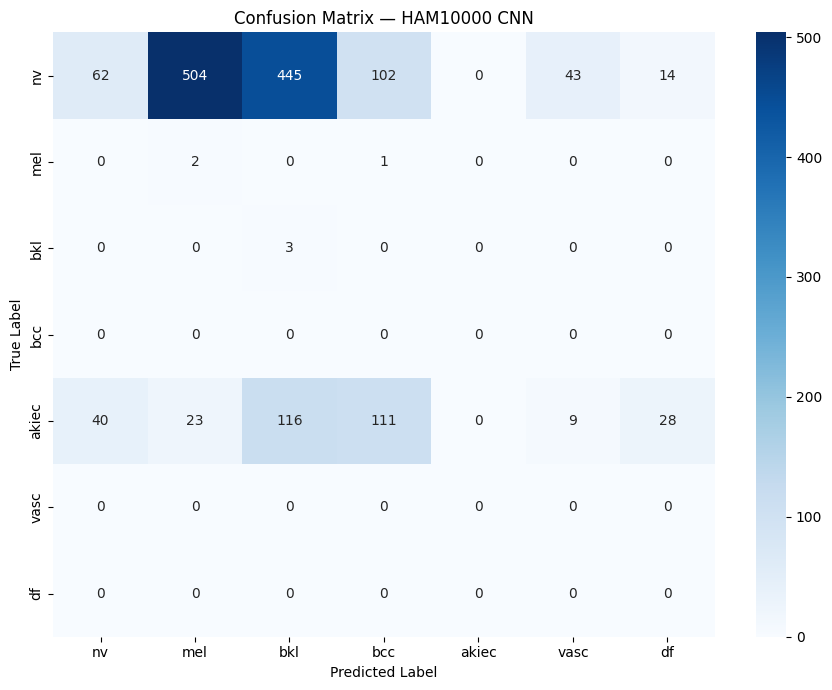

Confusion matrix saved ✅
Look at the diagonal — those are correct predictions
Off-diagonal = where the model gets confused


In [10]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix — HAM10000 CNN')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig("../model/confusion_matrix.png")
plt.show()

print("Confusion matrix saved ✅")
print("Look at the diagonal — those are correct predictions")
print("Off-diagonal = where the model gets confused")

In [11]:
from sklearn.metrics import balanced_accuracy_score
import numpy as np

bal_acc = balanced_accuracy_score(all_labels, all_preds)
print(f"Balanced Accuracy: {bal_acc*100:.1f}%")
print("(This accounts for class imbalance — more honest than regular accuracy)")
print(f"\nModel saved at: model/best_cnn.pth")
print(f"Loss curve at:  model/loss_curve.png")
print(f"Confusion matrix at: model/confusion_matrix.png")
print("\n✅ Day 4 complete — model fully trained and evaluated")

Balanced Accuracy: 43.0%
(This accounts for class imbalance — more honest than regular accuracy)

Model saved at: model/best_cnn.pth
Loss curve at:  model/loss_curve.png
Confusion matrix at: model/confusion_matrix.png

✅ Day 4 complete — model fully trained and evaluated


d:\nn-xai-agent\xai-env\lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
